In [5]:
"""
SSH numerical framework for periodic chain
Author: Zeynepnur Sahinel
Purpose:
    Numerical implementation of the SSH model and computation of
    band structure, correlation matrices, and entanglement measures.
"""

'\nSSH numerical framework for periodic chain\nAuthor: Zeynepnur Sahinel\nPurpose:\n    Numerical implementation of the SSH model and computation of\n    band structure, correlation matrices, and entanglement measures.\n'

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import os

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ============================================================
# SSH: common utilities, energy band plots, and occupation overlays
# ============================================================

def ssh_couplings(lam: float) -> tuple[float, float]:
    """t1 = 1 - lam,  t2 = 1 + lam"""
    return 1.0 - lam, 1.0 + lam

def ssh_dispersion_from_t1t2(k: np.ndarray, t1, t2) -> np.ndarray:
    """|h(k)| = sqrt(t1^2 + t2^2 + 2 t1 t2 cos k)"""
    return np.sqrt(t1**2 + t2**2 + 2.0*t1*t2*np.cos(k))

def ssh_energy_pm(k: np.ndarray, lam: float) -> tuple[np.ndarray, np.ndarray]:
    """E_-(k), E_+(k) using lam parametrization."""
    t1, t2 = ssh_couplings(lam)
    Ep = ssh_dispersion_from_t1t2(k, t1, t2)
    return -Ep, Ep

def make_figure_ssh_bands(
    lams_line=(-0.8, -0.4, 0.0, 0.4, 0.8),
    lam_range=(-1.0, 1.0),
    nk=400,
    nlam=400,
    cmap="inferno",
    savepath=None,
    show=True,
):
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_1_ssh_bands.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk)
    lam_grid = np.linspace(lam_range[0], lam_range[1], nlam)
    K, L = np.meshgrid(k, lam_grid)

    t1 = 1.0 + L
    t2 = 1.0 - L
    E2D = ssh_dispersion_from_t1t2(K, t1, t2)

    fig, axes = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)

    # Panel A
    ax1 = axes[0]
    for lam in lams_line:
        Em, Ep = ssh_energy_pm(k, lam)
        (line,) = ax1.plot(k, Ep, label=rf"$\lambda={lam}$")
        ax1.plot(k, Em, color=line.get_color())

    ax1.set_xlabel(r"$k$")
    ax1.set_ylabel("Energy")
    ax1.set_title(r"SSH band structure for different $\lambda$")
    ax1.legend()

    xticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

    # Panel B
    ax2 = axes[1]
    pcm = ax2.pcolormesh(K, L, E2D, shading="auto", cmap=cmap)
    ax2.set_xlabel(r"$k$")
    ax2.set_ylabel(r"$\lambda$")
    ax2.set_title(r"Upper SSH energy band $E_+(k,\lambda)$")
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    fig.colorbar(pcm, ax=ax2, label="Energy")

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, axes

def fermi_dirac(E: np.ndarray, beta: float) -> np.ndarray:
    """Fermi–Dirac distribution: n(E) = 1/(exp(beta E)+1)."""
    return 1.0 / (np.exp(beta * E) + 1.0)

def make_figure_upper_occupation_overlay(
    lam: float = 0.0,
    betas=(30, 5, 2, 1, 0.5),
    nk: int = 400,
    savepath: str | None = None,
    show: bool = True,
):
    """
    Single-panel overlay of n_+(k) for multiple betas at fixed lambda.
    Uses n_+(k) = 1/(exp(beta E_+(k))+1), with E_+(k)=|h(k)|.
    """
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_occ_overlay_lam{lam}.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk, endpoint=False)

    t1, t2 = ssh_couplings(lam)
    E_plus = ssh_dispersion_from_t1t2(k, t1, t2)

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.8))

    for beta in betas:
        n_plus = fermi_dirac(E_plus, beta)
        ax.plot(k, n_plus, label=rf"$\beta={beta}$")

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$n_+(k)$")
    ax.set_title(rf"Upper band occupation $n_+(k)$ (fixed $\lambda={lam}$)")

    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax.set_ylim(-0.02, 0.52)  # çünkü n_+ ∈ [0, 1/2] (mu=0 simetri)

    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

def make_figure_upper_occupation_overlay_lams(
    beta: float = 2.0,
    lams=(0.0, 0.1, 0.4, 0.8),
    nk: int = 400,
    savepath: str | None = None,
    show: bool = True,
):
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_occ_overlay_beta{beta}.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk, endpoint=False)

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.8))

    for lam in lams:
        t1, t2 = ssh_couplings(lam)
        E_plus = ssh_dispersion_from_t1t2(k, t1, t2)
        n_plus = fermi_dirac(E_plus, beta)
        ax.plot(k, n_plus, label=rf"$\lambda={lam}$")

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$n_+(k)$")
    ax.set_title(rf"Upper band occupation $n_+(k)$ (fixed $\beta={beta}$)")

    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax.set_ylim(-0.02, 0.52)

    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

# ============================================================
# Concurrence (continuum, Kim&Cho-style) utilities
# ============================================================

# k-grid for continuum integrals (periodic grid; endpoint=False önemli)
KS = np.linspace(0, 2*np.pi, 8192, endpoint=False)

def h_complex_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    """
    Bloch off-diagonal term: h(k) = t1 + t2 e^{-ik}.
    Uses our convention t1=1+lam, t2=1-lam (via ssh_couplings).
    """
    t1, t2 = ssh_couplings(lam)
    return t1 + t2 * np.exp(-1j * k)

def abs_h_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    return np.abs(h_complex_from_lam(lam, k))

def phi_k_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    # phase in (-0, 2pi]
    return np.angle(h_complex_from_lam(lam, k))

def eta_continuum(lam: float, beta=np.inf, r: int = 0, ks: np.ndarray = KS) -> float:
    """
    Continuum correlator amplitude:
      η_r(λ,β) = (1/2π) ∫ dk  tanh(β|h(k)|/2) cos(rk + φ(k))
        where r=m-n is the site separation, and φ(k) = arg(h(k)).
    beta = np.inf -> tanh(...) -> 1 (ground-state limit)
    """
    ph = phi_k_from_lam(lam, ks)
    if np.isinf(beta):
        w = 1.0
        return np.cos(r*ks + ph).mean()
    else:
        w = np.tanh(0.5 * beta * abs_h_from_lam(lam, ks))
        return (w * np.cos(r*ks + ph)).mean()

def concurrence_from_eta(eta: float) -> float:
    """
    For the X-state structure used in the report:
      C = max(0, 1/2 (eta^2 + 2|eta| - 1))
    This matches the Kim&Cho active branch at T=0 (eta>=0),
    and stays safe if eta changes sign.
    """
    return max(0.0, 0.5 * (eta**2 + 2.0*np.abs(eta) - 1.0))

def make_figure_concurrence_vs_lambda(
    lam_min=-1.0,
    lam_max=1.0,
    num=2001,
    beta=np.inf,
    ks=KS,
    savepath=None,
    show=True,
    title=None,
    mark_lambda0=True,
):
    """
    Kim & Cho Fig.2 style plot of concurrence vs lambda, with:
      - C1(λ)  (r=0)
      - C2(λ)  (r=1)
      - dC2/dλ (right axis)
    beta=np.inf -> ground-state limit
    beta finite  -> thermal
    """

    if savepath is None:
        tag = "T0" if np.isinf(beta) else f"beta{beta:g}"
        savepath = f"{FIG_DIR}/fig_concurrence_{tag}.pdf"

    lams = np.linspace(lam_min, lam_max, num)

    # compute eta and concurrence
    eta0 = np.array([eta_continuum(l, beta=beta, r=0, ks=ks) for l in lams])
    eta1 = np.array([eta_continuum(l, beta=beta, r=1, ks=ks) for l in lams])

    C1 = np.array([concurrence_from_eta(x) for x in eta0])
    C2 = np.array([concurrence_from_eta(x) for x in eta1])

    # derivative (clean + robust)
    dC2 = np.gradient(C2, lams)

    # ---- plot
    fig, axC = plt.subplots(figsize=(7.2, 4.6))
    axD = axC.twinx()

    ln1, = axC.plot(lams, C1, color="mediumorchid", lw=2, label=r"$C_1(\lambda)$")
    ln2, = axC.plot(lams, C2, color="seagreen",    lw=2, label=r"$C_2(\lambda)$")
    ln3, = axD.plot(lams, dC2, color="deepskyblue", lw=2, label=r"$\partial_\lambda C_2$")

    if mark_lambda0:
        axC.axvline(0.0, ls="--", lw=1)

    axC.set_xlabel(r"$\lambda$")
    axC.set_ylabel("Concurrence")
    axD.set_ylabel(r"$\partial_\lambda C_2$")

    tag = "T=0" if np.isinf(beta) else rf"$\beta={beta:g}$"
    axC.set_title(title or rf"Wootters concurrence ({tag})")

    # combined legend
    lines = [ln1, ln2, ln3]
    axC.legend(lines, [l.get_label() for l in lines], frameon=False, loc="upper left")

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, (axC, axD)

In [ ]:
#Energy band diagrams for the SSH model
#(a)Upper energy band E+(k) for selected lambdas
#(b)Upper energy band E+(k, lambda) heatmap
make_figure_ssh_bands()

In [ ]:
make_figure_upper_occupation_overlay(lam=0.0, betas=(30, 5, 2, 1, 0.5))

In [ ]:
make_figure_upper_occupation_overlay_lams(beta=5.0, lams=(0.0, 0.138, 0.4, 0.8))

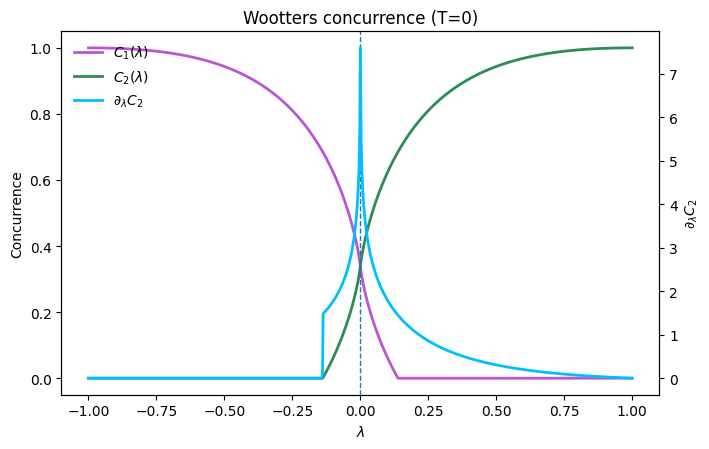

(<Figure size 720x460 with 2 Axes>,
 (<Axes: title={'center': 'Wootters concurrence (T=0)'}, xlabel='$\\lambda$', ylabel='Concurrence'>,
  <Axes: ylabel='$\\partial_\\lambda C_2$'>))

In [30]:
make_figure_concurrence_vs_lambda(beta=np.inf)